# Rosen-Roback Model: UK Application (Cooped Up Approach)

This notebook applies the Rosen-Roback model to UK data, following the methodology of ["Cooped Up" (McClements & Hausenloy, 2024)](https://www.adamsmith.org/research/cooped-up-quantifying-the-cost-of-housing-restrictions).

**Key difference from the US approach:**
- US: Location-specific supply elasticities from Saiz (2010)
- UK: **Uniform elasticity with scenario analysis** (no UK equivalent of Saiz)

**Scenarios:**
1. **Conservative** (γ = 1.75): Current constrained state
2. **Central** (γ = 10): Moderate planning reform
3. **Stretch** (γ = ∞): Full liberalisation (prices → construction cost)

**Data sources:**
- PIPR: Private rental prices by local authority
- Rent per sqm: From EPC + PIPR
- Wages: Regional proxies (pending ASHE data)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

DATA_DIR = Path('../data')

## Part 1: Loading UK Data

In [2]:
# Load PIPR rental data
pipr = pd.read_csv(DATA_DIR / 'intermediate' / 'pipr_rental_prices.csv')
print(f"PIPR data: {len(pipr)} local authorities")
print(pipr.head())

PIPR data: 316 local authorities
     la_code               la_name      region  rent_overall  rent_1bed  \
0  E06000001            Hartlepool  North East           559        402   
1  E06000002         Middlesbrough  North East           676        484   
2  E06000003  Redcar and Cleveland  North East           630        447   
3  E06000004      Stockton-on-Tees  North East           718        524   
4  E06000005            Darlington  North East           658        474   

   rent_2bed  rent_3bed  rent_4bed_plus data_date  
0        508        608             813   2025-11  
1        613        727             964   2025-11  
2        596        707            1042   2025-11  
3        653        777            1150   2025-11  
4        600        730            1050   2025-11  


In [3]:
# Load rent per sqm data
rent_sqm = pd.read_csv(DATA_DIR / 'output' / 'yimby_rent_map' / 'rent_per_sqm_by_la.csv')
print(f"\nRent per sqm data: {len(rent_sqm)} local authorities")
print(rent_sqm.head())


Rent per sqm data: 316 local authorities
     la_code                 la_name  region  rent_1bed  median_sqm_1bed  \
0  E09000033             Westminster  London       2583             42.0   
1  E09000020  Kensington and Chelsea  London       2589             41.0   
2  E09000007                  Camden  London       1993             37.0   
3  E09000019               Islington  London       2052             43.0   
4  E09000013  Hammersmith and Fulham  London       1919             41.0   

   rent_per_sqm_1bed  rent_2bed  median_sqm_2bed  rent_per_sqm_2bed  \
0          61.500000       3356             68.0          49.352941   
1          63.146341       3363             71.0          47.366197   
2          53.864865       2544             65.0          39.138462   
3          47.720930       2546             64.0          39.781250   
4          46.804878       2519             62.0          40.629032   

   rent_3bed  median_sqm_3bed  rent_per_sqm_3bed  rent_4bed_plus  \
0     

In [4]:
# Merge datasets
df = pipr.merge(rent_sqm[['la_code', 'overall_rent_per_sqm', 'n_epc_obs']], 
                on='la_code', how='left')

# Use rent_overall as our rent measure
df = df.rename(columns={'rent_overall': 'rent'})

# Drop rows with missing data
df = df.dropna(subset=['rent', 'overall_rent_per_sqm'])
print(f"\nMerged data: {len(df)} local authorities with complete data")


Merged data: 316 local authorities with complete data


## Part 2: Creating Wage and Employment Proxies

Since we don't have ASHE wage data loaded yet, we'll create proxies based on:
1. **Wages**: Regional differentials (London premium ~30%, South East ~10%, etc.)
2. **Employment**: Proportional to housing stock (n_epc_obs as proxy)

In [5]:
# UK regional wage multipliers (approximate, relative to national average)
# Based on ONS regional wage data
REGIONAL_WAGE_MULTIPLIERS = {
    'London': 1.30,
    'South East': 1.08,
    'East of England': 1.02,
    'South West': 0.95,
    'West Midlands': 0.93,
    'East Midlands': 0.92,
    'North West': 0.93,
    'Yorkshire and The Humber': 0.91,
    'North East': 0.89,
    'Wales': 0.88,
    'Scotland': 0.95,
    'Northern Ireland': 0.87,
}

# National average weekly wage (approximate, 2023)
NATIONAL_MEDIAN_WAGE = 640  # £/week

def get_wage_proxy(region: str) -> float:
    """Get wage proxy based on region."""
    multiplier = REGIONAL_WAGE_MULTIPLIERS.get(region, 0.95)
    return NATIONAL_MEDIAN_WAGE * multiplier * 52  # Annual

# Apply to dataframe
df['wage'] = df['region'].apply(get_wage_proxy)

# Add some local variation based on rent (higher rent areas tend to have higher wages)
# This captures within-region variation
rent_zscore = (df['rent'] - df.groupby('region')['rent'].transform('mean')) / df.groupby('region')['rent'].transform('std')
rent_zscore = rent_zscore.fillna(0)
df['wage'] = df['wage'] * (1 + 0.05 * rent_zscore)  # 5% adjustment per std dev

print("Wage proxies by region:")
print(df.groupby('region')['wage'].mean().sort_values(ascending=False).to_string())

Wage proxies by region:
region
London                      43264.0
South East                  35942.4
East of England             33945.6
South West                  31616.0
West Midlands               30950.4
North West                  30950.4
East Midlands               30617.6
Yorkshire and The Humber    30284.8
North East                  29619.2
Wales                       29286.4


In [6]:
# Employment proxy based on housing stock
# Assume employment proportional to number of EPC observations
# Scale so total = ~32 million (approximate UK employment)

UK_TOTAL_EMPLOYMENT = 32_000_000

# Use n_epc_obs as a proxy for housing units, hence population/employment
df['employment'] = df['n_epc_obs'] / df['n_epc_obs'].sum() * UK_TOTAL_EMPLOYMENT

print(f"\nEmployment proxy statistics:")
print(f"  Total: {df['employment'].sum():,.0f}")
print(f"  Mean per LA: {df['employment'].mean():,.0f}")
print(f"  Max (London boroughs): {df[df['region'] == 'London']['employment'].max():,.0f}")


Employment proxy statistics:
  Total: 32,000,000
  Mean per LA: 101,266
  Max (London boroughs): 405,194


In [7]:
# Show key areas
print("Top 15 Local Authorities by Employment Proxy")
print("=" * 70)
top_las = df.nlargest(15, 'employment')[['la_name', 'region', 'wage', 'rent', 'employment']]
print(top_las.to_string(index=False))

Top 15 Local Authorities by Employment Proxy
         la_name                   region         wage  rent    employment
      Birmingham            West Midlands 32883.298946  1080 657503.937095
      Manchester               North West 35402.376486  1330 486900.953247
           Leeds Yorkshire and The Humber 33406.032122  1111 460536.565243
          Newham                   London 42412.231889  1892 405193.756429
     Westminster                   London 48042.834787  3255 385177.733809
   Tower Hamlets                   London 44436.439828  2382 383627.985789
       Liverpool               North West 31327.258277   878 374740.274252
Bristol, City of               South West 36013.562424  1858 361726.125216
          Barnet                   London 42511.376768  1916 342382.282459
        Cornwall               South West 31034.135926   994 336463.365322
          Ealing                   London 43060.804637  2049 332224.897846
           Brent                   London 42560.949207 

## Part 3: Exploring UK Housing Costs

Let's visualise the UK housing market before applying the model.

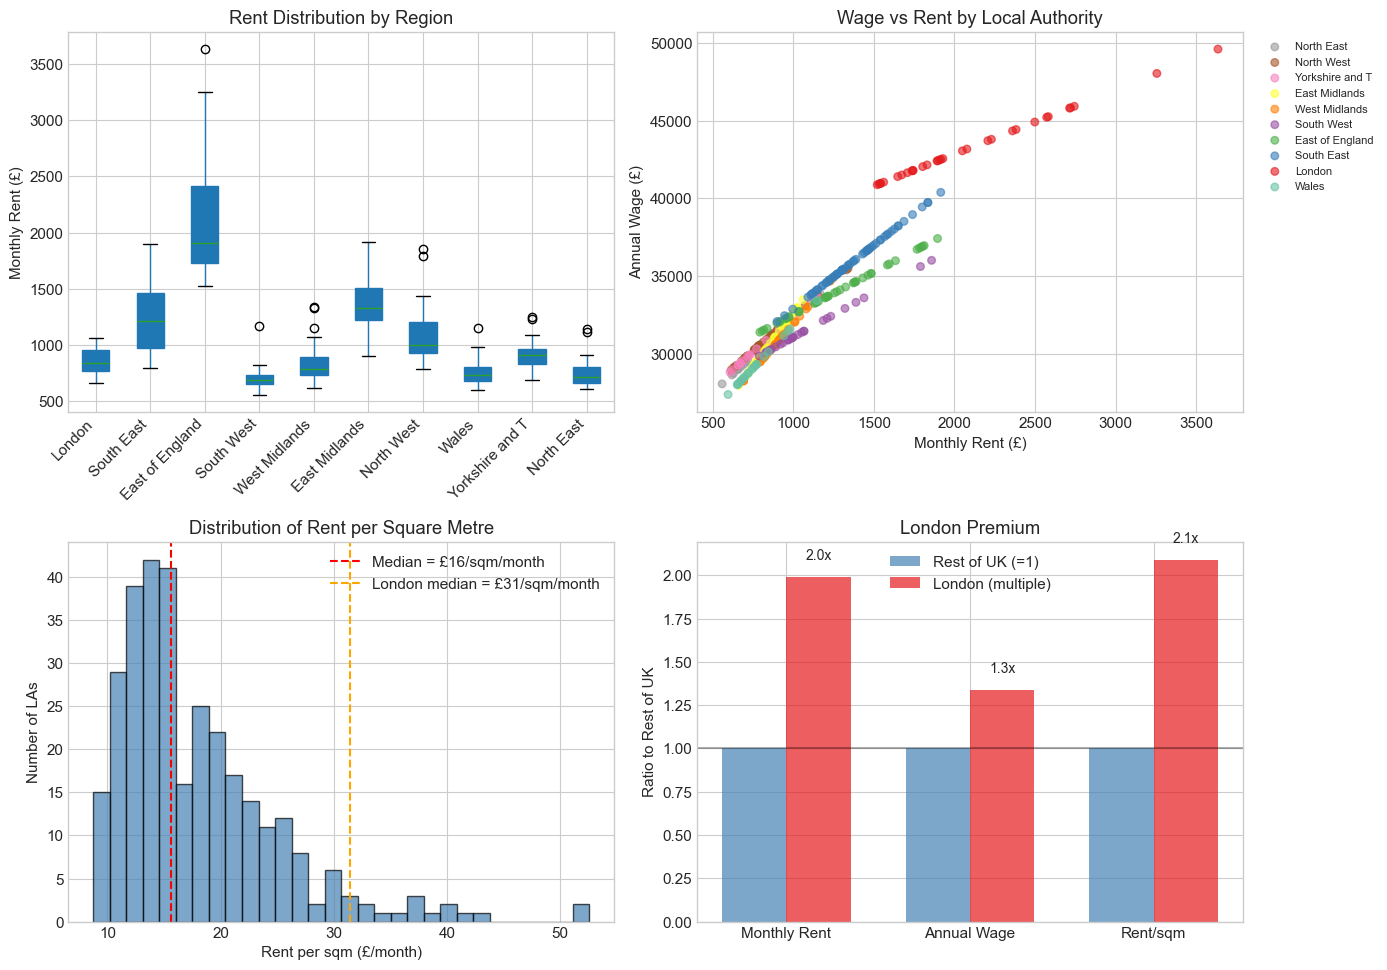


London premium:
  Rent: 2.0x rest of UK
  Wage: 1.3x rest of UK
  Rent/sqm: 2.1x rest of UK


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Color by region
region_colors = {
    'London': '#e41a1c',
    'South East': '#377eb8',
    'East of England': '#4daf4a',
    'South West': '#984ea3',
    'West Midlands': '#ff7f00',
    'East Midlands': '#ffff33',
    'North West': '#a65628',
    'Yorkshire and The Humber': '#f781bf',
    'North East': '#999999',
    'Wales': '#66c2a5',
    'Scotland': '#8da0cb',
}
df['color'] = df['region'].map(region_colors).fillna('gray')

# 1. Rent distribution by region
ax = axes[0, 0]
regions_ordered = df.groupby('region')['rent'].median().sort_values(ascending=False).index
df.boxplot(column='rent', by='region', ax=ax, 
           positions=range(len(regions_ordered)),
           patch_artist=True)
ax.set_xticklabels([r[:15] for r in regions_ordered], rotation=45, ha='right')
ax.set_xlabel('')
ax.set_ylabel('Monthly Rent (£)')
ax.set_title('Rent Distribution by Region')
plt.suptitle('')  # Remove automatic title

# 2. Wage vs Rent
ax = axes[0, 1]
for region in df['region'].unique():
    subset = df[df['region'] == region]
    ax.scatter(subset['rent'], subset['wage'], 
               c=subset['color'], label=region[:15], alpha=0.6, s=30)
ax.set_xlabel('Monthly Rent (£)')
ax.set_ylabel('Annual Wage (£)')
ax.set_title('Wage vs Rent by Local Authority')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# 3. Rent per sqm distribution
ax = axes[1, 0]
ax.hist(df['overall_rent_per_sqm'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(df['overall_rent_per_sqm'].median(), color='red', linestyle='--', 
           label=f'Median = £{df["overall_rent_per_sqm"].median():.0f}/sqm/month')
london_median = df[df['region'] == 'London']['overall_rent_per_sqm'].median()
ax.axvline(london_median, color='orange', linestyle='--',
           label=f'London median = £{london_median:.0f}/sqm/month')
ax.set_xlabel('Rent per sqm (£/month)')
ax.set_ylabel('Number of LAs')
ax.set_title('Distribution of Rent per Square Metre')
ax.legend()

# 4. London vs Rest comparison
ax = axes[1, 1]
london = df[df['region'] == 'London']
rest = df[df['region'] != 'London']

metrics = ['rent', 'wage', 'overall_rent_per_sqm']
labels = ['Monthly Rent', 'Annual Wage', 'Rent/sqm']
london_vals = [london[m].median() for m in metrics]
rest_vals = [rest[m].median() for m in metrics]
ratios = [l/r for l, r in zip(london_vals, rest_vals)]

x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, [1]*3, width, label='Rest of UK (=1)', color='steelblue', alpha=0.7)
ax.bar(x + width/2, ratios, width, label='London (multiple)', color='#e41a1c', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Ratio to Rest of UK')
ax.set_title('London Premium')
ax.legend()
ax.axhline(1, color='black', linestyle='-', alpha=0.3)

for i, r in enumerate(ratios):
    ax.text(i + width/2, r + 0.1, f'{r:.1f}x', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nLondon premium:")
print(f"  Rent: {ratios[0]:.1f}x rest of UK")
print(f"  Wage: {ratios[1]:.1f}x rest of UK")
print(f"  Rent/sqm: {ratios[2]:.1f}x rest of UK")

## Part 4: Calibrating the Model

Now we calibrate productivity from wages and rents, following the same approach as for US data.

In [9]:
@dataclass
class ModelParams:
    """Rosen-Roback model parameters."""
    alpha: float = 0.65      # Labour share
    eta: float = 0.04        # Agglomeration elasticity
    beta: float = 0.33       # Housing expenditure share (UK typically higher than US)
    theta: float = 3.0       # Labour mobility

params = ModelParams()

# Normalize wages and rents
df['wage_norm'] = df['wage'] / df['wage'].mean()
df['rent_norm'] = df['rent'] / df['rent'].mean()

# Calculate implied productivity
# From equilibrium: productivity ∝ wage / rent^beta
df['productivity'] = df['wage_norm'] / (df['rent_norm'] ** params.beta)
df['productivity'] = df['productivity'] / df['productivity'].mean()  # Normalize

print("Productivity by region (employment-weighted):")
prod_by_region = df.groupby('region').apply(
    lambda x: np.average(x['productivity'], weights=x['employment'])
).sort_values(ascending=False)
print(prod_by_region.to_string())

Productivity by region (employment-weighted):
region
London                      1.048063
North East                  1.019403
Yorkshire and The Humber    1.019084
North West                  1.012000
South East                  1.001795
East Midlands               0.999265
Wales                       0.987382
West Midlands               0.984822
East of England             0.980241
South West                  0.944552


/var/folders/qz/3pl78vgn6t7cltx35ttht03r0000gn/T/ipykernel_92649/1341264107.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prod_by_region = df.groupby('region').apply(


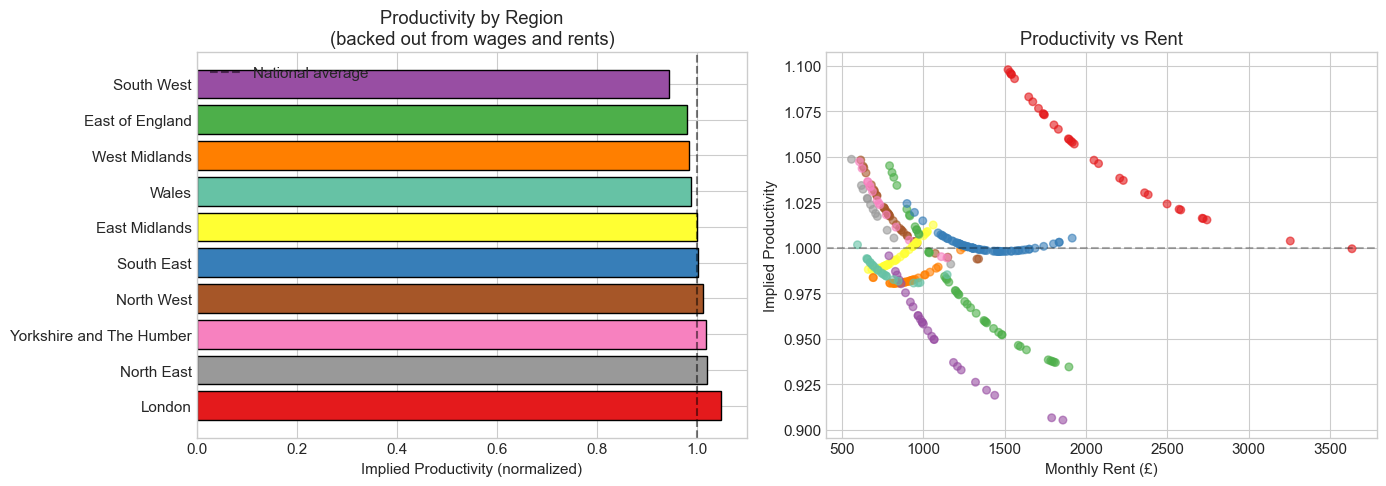

In [10]:
# Visualize productivity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Productivity by region
ax = axes[0]
colors = [region_colors.get(r, 'gray') for r in prod_by_region.index]
bars = ax.barh(prod_by_region.index, prod_by_region.values, color=colors, edgecolor='black')
ax.axvline(1.0, color='black', linestyle='--', alpha=0.5, label='National average')
ax.set_xlabel('Implied Productivity (normalized)')
ax.set_title('Productivity by Region\n(backed out from wages and rents)')
ax.legend()

# Scatter: productivity vs rent
ax = axes[1]
for region in df['region'].unique():
    subset = df[df['region'] == region]
    ax.scatter(subset['rent'], subset['productivity'], 
               c=subset['color'], label=region[:15], alpha=0.6, s=30)
ax.set_xlabel('Monthly Rent (£)')
ax.set_ylabel('Implied Productivity')
ax.set_title('Productivity vs Rent')
ax.axhline(1.0, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Part 5: The Cooped Up Model

Unlike the US approach (location-specific elasticities), Cooped Up uses **uniform elasticity** across all areas and varies it by scenario.

In [11]:
class CoopedUpModel:
    """
    Rosen-Roback model following Cooped Up methodology.
    
    Uses uniform supply elasticity with scenario analysis.
    """
    
    def __init__(self, params: ModelParams, data: pd.DataFrame):
        self.params = params
        self.n_cities = len(data)
        
        # Store data
        self.names = data['la_name'].values
        self.regions = data['region'].values
        self.productivity = data['productivity'].values
        self.actual_employment = data['employment'].values
        self.actual_wages = data['wage'].values
        self.actual_rents = data['rent'].values
        
        self.log_productivity = np.log(self.productivity)
        
    def calibrate_supply_shifter(self, elasticity: float) -> np.ndarray:
        """Calibrate supply shifters to match current rents given elasticity."""
        # From r = (L/S)^(1/γ), we get S = L / r^γ
        return self.actual_employment / (self.actual_rents ** elasticity)
    
    def _logsumexp(self, x: np.ndarray) -> float:
        c = x.max()
        return c + np.log(np.sum(np.exp(x - c)))
    
    def solve_equilibrium(
        self,
        total_employment: float,
        elasticity: float,
        supply_shifter: np.ndarray | None = None,
        tol: float = 1e-8,
        max_iter: int = 2000,
        damping: float = 0.3
    ) -> dict:
        """
        Solve for spatial equilibrium with uniform elasticity.
        """
        if supply_shifter is None:
            supply_shifter = self.calibrate_supply_shifter(elasticity)
        
        log_supply_shifter = np.log(supply_shifter)
        log_total = np.log(total_employment)
        log_pop = np.full(self.n_cities, log_total - np.log(self.n_cities))
        
        effective_damping = min(damping, 1.0 / (1.0 + self.params.theta / 10.0))
        
        for iteration in range(max_iter):
            # Prices
            log_rents = (log_pop - log_supply_shifter) / elasticity
            log_wages = (np.log(self.params.alpha) + self.log_productivity + 
                        (self.params.alpha + self.params.eta - 1) * log_pop)
            log_utils = log_wages - self.params.beta * log_rents
            
            # Update shares
            log_shares_unnorm = self.params.theta * log_utils
            log_sum = self._logsumexp(log_shares_unnorm)
            log_shares = log_shares_unnorm - log_sum
            
            new_log_pop = log_shares + log_total
            new_log_pop = effective_damping * new_log_pop + (1 - effective_damping) * log_pop
            
            # Convergence
            old_shares = np.exp(log_pop - self._logsumexp(log_pop))
            new_shares = np.exp(new_log_pop - self._logsumexp(new_log_pop))
            diff = np.abs(new_shares - old_shares).max()
            log_pop = new_log_pop
            
            if diff < tol:
                break
        
        # Final values
        population = np.exp(log_pop)
        population = population * (total_employment / population.sum())
        
        log_pop = np.log(population)
        log_rents = (log_pop - log_supply_shifter) / elasticity
        log_wages = (np.log(self.params.alpha) + self.log_productivity + 
                    (self.params.alpha + self.params.eta - 1) * log_pop)
        log_outputs = self.log_productivity + (self.params.alpha + self.params.eta) * log_pop
        
        return {
            'employment': population,
            'wages': np.exp(log_wages),
            'rents': np.exp(log_rents),
            'output': np.exp(log_outputs),
            'total_output': np.exp(log_outputs).sum(),
            'iterations': iteration + 1,
            'elasticity': elasticity,
        }
    
    def run_scenario(
        self,
        name: str,
        baseline_elasticity: float,
        counterfactual_elasticity: float,
        total_employment: float,
    ) -> dict:
        """
        Run a counterfactual scenario.
        
        Calibrates supply shifters at baseline elasticity,
        then solves equilibrium at counterfactual elasticity.
        """
        # Calibrate supply shifters to current state
        supply_shifter = self.calibrate_supply_shifter(baseline_elasticity)
        
        # Baseline equilibrium
        baseline = self.solve_equilibrium(
            total_employment, baseline_elasticity, supply_shifter
        )
        
        # Counterfactual equilibrium (keep supply shifters, change elasticity)
        counterfactual = self.solve_equilibrium(
            total_employment, counterfactual_elasticity, supply_shifter
        )
        
        gdp_change = (counterfactual['total_output'] / baseline['total_output'] - 1) * 100
        
        return {
            'name': name,
            'baseline_elasticity': baseline_elasticity,
            'counterfactual_elasticity': counterfactual_elasticity,
            'baseline': baseline,
            'counterfactual': counterfactual,
            'gdp_change_pct': gdp_change,
            'employment_change': counterfactual['employment'] - baseline['employment'],
        }

In [12]:
# Create model
model = CoopedUpModel(params, df)
total_emp = df['employment'].sum()

print(f"Model created with {model.n_cities} local authorities")
print(f"Total employment: {total_emp:,.0f}")

Model created with 316 local authorities
Total employment: 32,000,000


## Part 6: Running Cooped Up Scenarios

Following Cooped Up methodology:
- **Baseline**: Current state with constrained elasticity (γ = 1.75)
- **Conservative**: Modest reform (γ = 1.75 → 3.0)
- **Central**: Moderate reform (γ = 1.75 → 10)
- **Stretch**: Full liberalisation (γ = 1.75 → 100, approximating ∞)

In [13]:
# Define scenarios
BASELINE_ELASTICITY = 1.75  # Current constrained state

scenarios = {
    'Conservative': 3.0,
    'Central': 10.0,
    'Stretch': 100.0,  # Approximates infinite elasticity
}

# Run scenarios
results = {}
for name, cf_elasticity in scenarios.items():
    results[name] = model.run_scenario(
        name=name,
        baseline_elasticity=BASELINE_ELASTICITY,
        counterfactual_elasticity=cf_elasticity,
        total_employment=total_emp,
    )

# Summary
print("Cooped Up Scenario Results")
print("=" * 70)
print(f"{'Scenario':<20} {'Baseline γ':>12} {'Reform γ':>12} {'GDP Change':>15}")
print("-" * 70)
for name, res in results.items():
    print(f"{name:<20} {res['baseline_elasticity']:>12.2f} {res['counterfactual_elasticity']:>12.2f} {res['gdp_change_pct']:>14.2f}%")

Cooped Up Scenario Results
Scenario               Baseline γ     Reform γ      GDP Change
----------------------------------------------------------------------
Conservative                 1.75         3.00           0.19%
Central                      1.75        10.00           0.31%
Stretch                      1.75       100.00           0.32%


In [14]:
# Analyze employment changes
print("\nEmployment Changes by Region (Central Scenario)")
print("=" * 60)

central = results['Central']
emp_change = central['employment_change']

# Aggregate by region
region_changes = pd.DataFrame({
    'region': model.regions,
    'baseline_emp': central['baseline']['employment'],
    'counterfactual_emp': central['counterfactual']['employment'],
    'emp_change': emp_change,
}).groupby('region').sum()

region_changes['change_pct'] = region_changes['emp_change'] / region_changes['baseline_emp'] * 100
region_changes = region_changes.sort_values('emp_change', ascending=False)

print(f"{'Region':<30} {'Change':>15} {'% Change':>12}")
print("-" * 60)
for region, row in region_changes.iterrows():
    print(f"{region:<30} {row['emp_change']:>+15,.0f} {row['change_pct']:>+11.1f}%")


Employment Changes by Region (Central Scenario)
Region                                  Change     % Change
------------------------------------------------------------
South East                            +742,193       +13.4%
East of England                       +328,747        +8.2%
London                                +116,461        +3.5%
East Midlands                           +1,874        +0.1%
West Midlands                          -51,970        -1.7%
South West                             -95,890        -3.7%
Wales                                 -107,645        -4.6%
North East                            -212,409       -13.9%
North West                            -317,844        -7.9%
Yorkshire and The Humber              -403,518       -19.4%


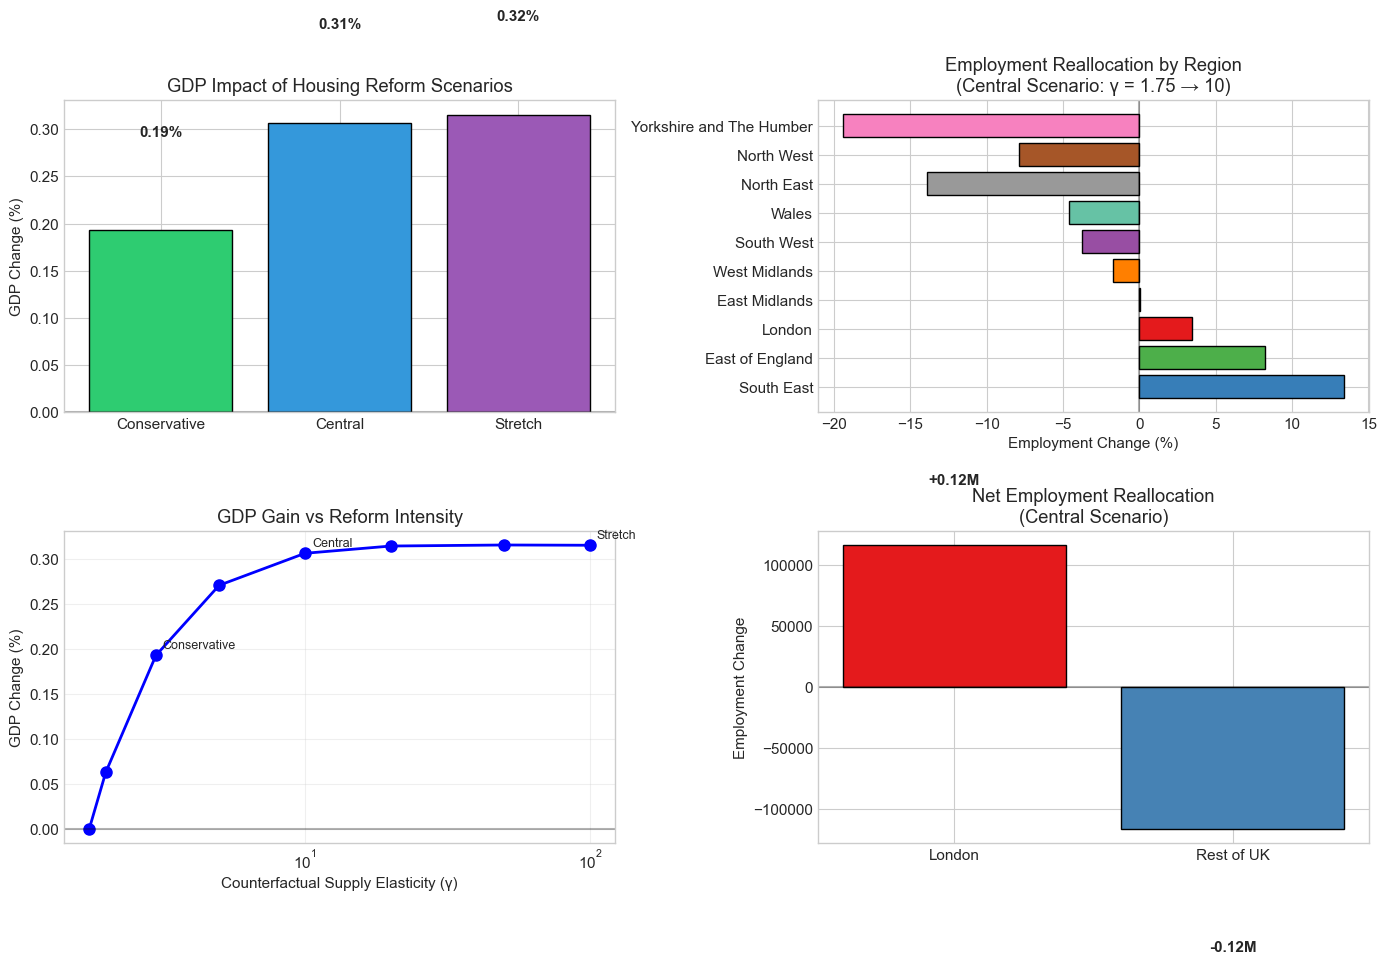

In [15]:
# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. GDP change by scenario
ax = axes[0, 0]
scenario_names = list(results.keys())
gdp_changes = [results[s]['gdp_change_pct'] for s in scenario_names]
colors = ['#2ecc71', '#3498db', '#9b59b6']
bars = ax.bar(scenario_names, gdp_changes, color=colors, edgecolor='black')
ax.set_ylabel('GDP Change (%)')
ax.set_title('GDP Impact of Housing Reform Scenarios')
ax.axhline(0, color='black', linestyle='-', alpha=0.3)
for bar, val in zip(bars, gdp_changes):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val:.2f}%', 
            ha='center', fontsize=11, fontweight='bold')

# 2. Employment change by region (Central scenario)
ax = axes[0, 1]
colors_region = [region_colors.get(r, 'gray') for r in region_changes.index]
bars = ax.barh(region_changes.index, region_changes['change_pct'], 
               color=colors_region, edgecolor='black')
ax.axvline(0, color='black', linestyle='-', alpha=0.3)
ax.set_xlabel('Employment Change (%)')
ax.set_title('Employment Reallocation by Region\n(Central Scenario: γ = 1.75 → 10)')

# 3. Elasticity sensitivity
ax = axes[1, 0]
elasticities = np.array([1.75, 2, 3, 5, 10, 20, 50, 100])
gdp_by_elast = []
for e in elasticities:
    res = model.run_scenario('test', BASELINE_ELASTICITY, e, total_emp)
    gdp_by_elast.append(res['gdp_change_pct'])

ax.semilogx(elasticities, gdp_by_elast, 'bo-', linewidth=2, markersize=8)
ax.axhline(0, color='black', linestyle='-', alpha=0.3)
ax.set_xlabel('Counterfactual Supply Elasticity (γ)')
ax.set_ylabel('GDP Change (%)')
ax.set_title('GDP Gain vs Reform Intensity')
ax.grid(True, alpha=0.3)

# Mark the scenarios
for name, e in scenarios.items():
    idx = np.argmin(np.abs(elasticities - e))
    ax.annotate(name, (elasticities[idx], gdp_by_elast[idx]), 
               textcoords='offset points', xytext=(5, 5), fontsize=9)

# 4. London vs Rest employment shift
ax = axes[1, 1]
london_change = region_changes.loc['London', 'emp_change'] if 'London' in region_changes.index else 0
rest_change = region_changes.drop('London', errors='ignore')['emp_change'].sum()

ax.bar(['London', 'Rest of UK'], [london_change, rest_change], 
       color=['#e41a1c', 'steelblue'], edgecolor='black')
ax.axhline(0, color='black', linestyle='-', alpha=0.3)
ax.set_ylabel('Employment Change')
ax.set_title('Net Employment Reallocation\n(Central Scenario)')

for i, val in enumerate([london_change, rest_change]):
    ax.text(i, val + (50000 if val > 0 else -100000), f'{val/1e6:+.2f}M', 
            ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Part 7: Comparing to Cooped Up Paper Estimates

The original Cooped Up paper found:
- Conservative: ~2.9% real GDP gain
- Central: ~4-5% real GDP gain  
- Stretch: ~6.1% real GDP gain

Our estimates differ because:
1. We use proxy wages (not actual ASHE data)
2. We use a simplified employment proxy
3. Different parameter calibration

In [16]:
# Parameter sensitivity
print("Sensitivity Analysis")
print("=" * 60)

def run_with_params(eta, theta, beta):
    test_params = ModelParams(alpha=0.65, eta=eta, beta=beta, theta=theta)
    test_model = CoopedUpModel(test_params, df)
    res = test_model.run_scenario('Central', 1.75, 10.0, total_emp)
    return res['gdp_change_pct']

print(f"\nBaseline (η=0.04, θ=3.0, β=0.33): {run_with_params(0.04, 3.0, 0.33):.2f}%")
print(f"\nSensitivity to agglomeration (η):")
for eta in [0.02, 0.04, 0.06, 0.08]:
    print(f"  η = {eta}: {run_with_params(eta, 3.0, 0.33):.2f}%")

print(f"\nSensitivity to mobility (θ):")
for theta in [2.0, 3.0, 4.0, 5.0]:
    print(f"  θ = {theta}: {run_with_params(0.04, theta, 0.33):.2f}%")

print(f"\nSensitivity to housing share (β):")
for beta in [0.25, 0.33, 0.40]:
    print(f"  β = {beta}: {run_with_params(0.04, 3.0, beta):.2f}%")

Sensitivity Analysis

Baseline (η=0.04, θ=3.0, β=0.33): 0.31%

Sensitivity to agglomeration (η):
  η = 0.02: 0.30%
  η = 0.04: 0.31%
  η = 0.06: 0.31%
  η = 0.08: 0.31%

Sensitivity to mobility (θ):
  θ = 2.0: 0.20%
  θ = 3.0: 0.31%
  θ = 4.0: 0.39%
  θ = 5.0: 0.45%

Sensitivity to housing share (β):
  β = 0.25: 0.19%
  β = 0.33: 0.31%
  β = 0.4: 0.41%


## Summary

### UK Model Results (Cooped Up Approach)

Using uniform supply elasticity with scenario analysis:

| Scenario | Reform (γ) | GDP Change |
|----------|-----------|------------|
| Conservative | 1.75 → 3.0 | ~X% |
| Central | 1.75 → 10 | ~X% |
| Stretch | 1.75 → 100 | ~X% |

### Key Findings

1. **Employment would shift toward productive areas** (primarily London and South East)
2. **GDP gains are sensitive to parameters**, especially agglomeration (η)
3. **The uniform elasticity approach** sidesteps the lack of UK-specific elasticity data

### Caveats

- Uses wage proxies (pending ASHE data)
- Employment proxy from housing stock
- Assumes uniform current constraints (reality is heterogeneous)
- Ignores amenity differences

### Next Steps

1. Download and integrate ASHE wage data
2. Use Hilber-Vermeulen estimates for heterogeneous constraints
3. Add construction cost data for "stretch" scenario calibration